# Clase 21: Estrategias de trading con opciones 1

> **Objetivo:** Construir y analizar las estrategias que expresan una visión sobre el movimiento del mercado, straddle, strangle, bull spread y bear spread. Entender qué vista del mercado expresa cada una, cuándo usarla, y cómo se relaciona con la volatilidad implícita.
> 

---

Esta clase usa las funciones `payoff_estrategia()` y `graficar_estrategia()` definidas en la Clase 19. 

---

## 1. Estrategia direccional

Una estrategia direccional gana cuando el precio del subyacente se mueve en una dirección específica, o simplemente cuando se mueve lo suficiente. Se construyen combinando posiciones básicas de la Clase 19.

**Apuestan al movimiento**, ya sea hacia arriba, hacia abajo, o en cualquier dirección pero con suficiente magnitud.

---

## Estrategia neutral

Las estrategias neutrales ganan cuando el subyacente **no se mueve mucho**, cuando el precio se queda dentro de un rango predefinido. Son posiciones de **venta de volatilidad**: cobras prima hoy a cambio de asumir el riesgo de que el mercado se mueva demasiado.

Cuando la IV es alta, las primas son caras y vender volatilidad es más atractivo. Un trader que ve la superficie de volatilidad con IV elevada en opciones de corto plazo tiene un incentivo natural a construir estrategias neutrales pues cobra más prima por el mismo riesgo.

En términos de griegas, estas estrategias tienen **vega negativa y theta positiva**: pierden si la IV sube, pero ganan dinero todos los días por el simple paso del tiempo.

## 2. Long Straddle

### ¿Qué es?

Compra simultánea de un call y un put con el **mismo strike y vencimiento**. La posición gana si el subyacente se mueve significativamente en cualquier dirección. Pierde si el precio termina cerca del strike al vencimiento.

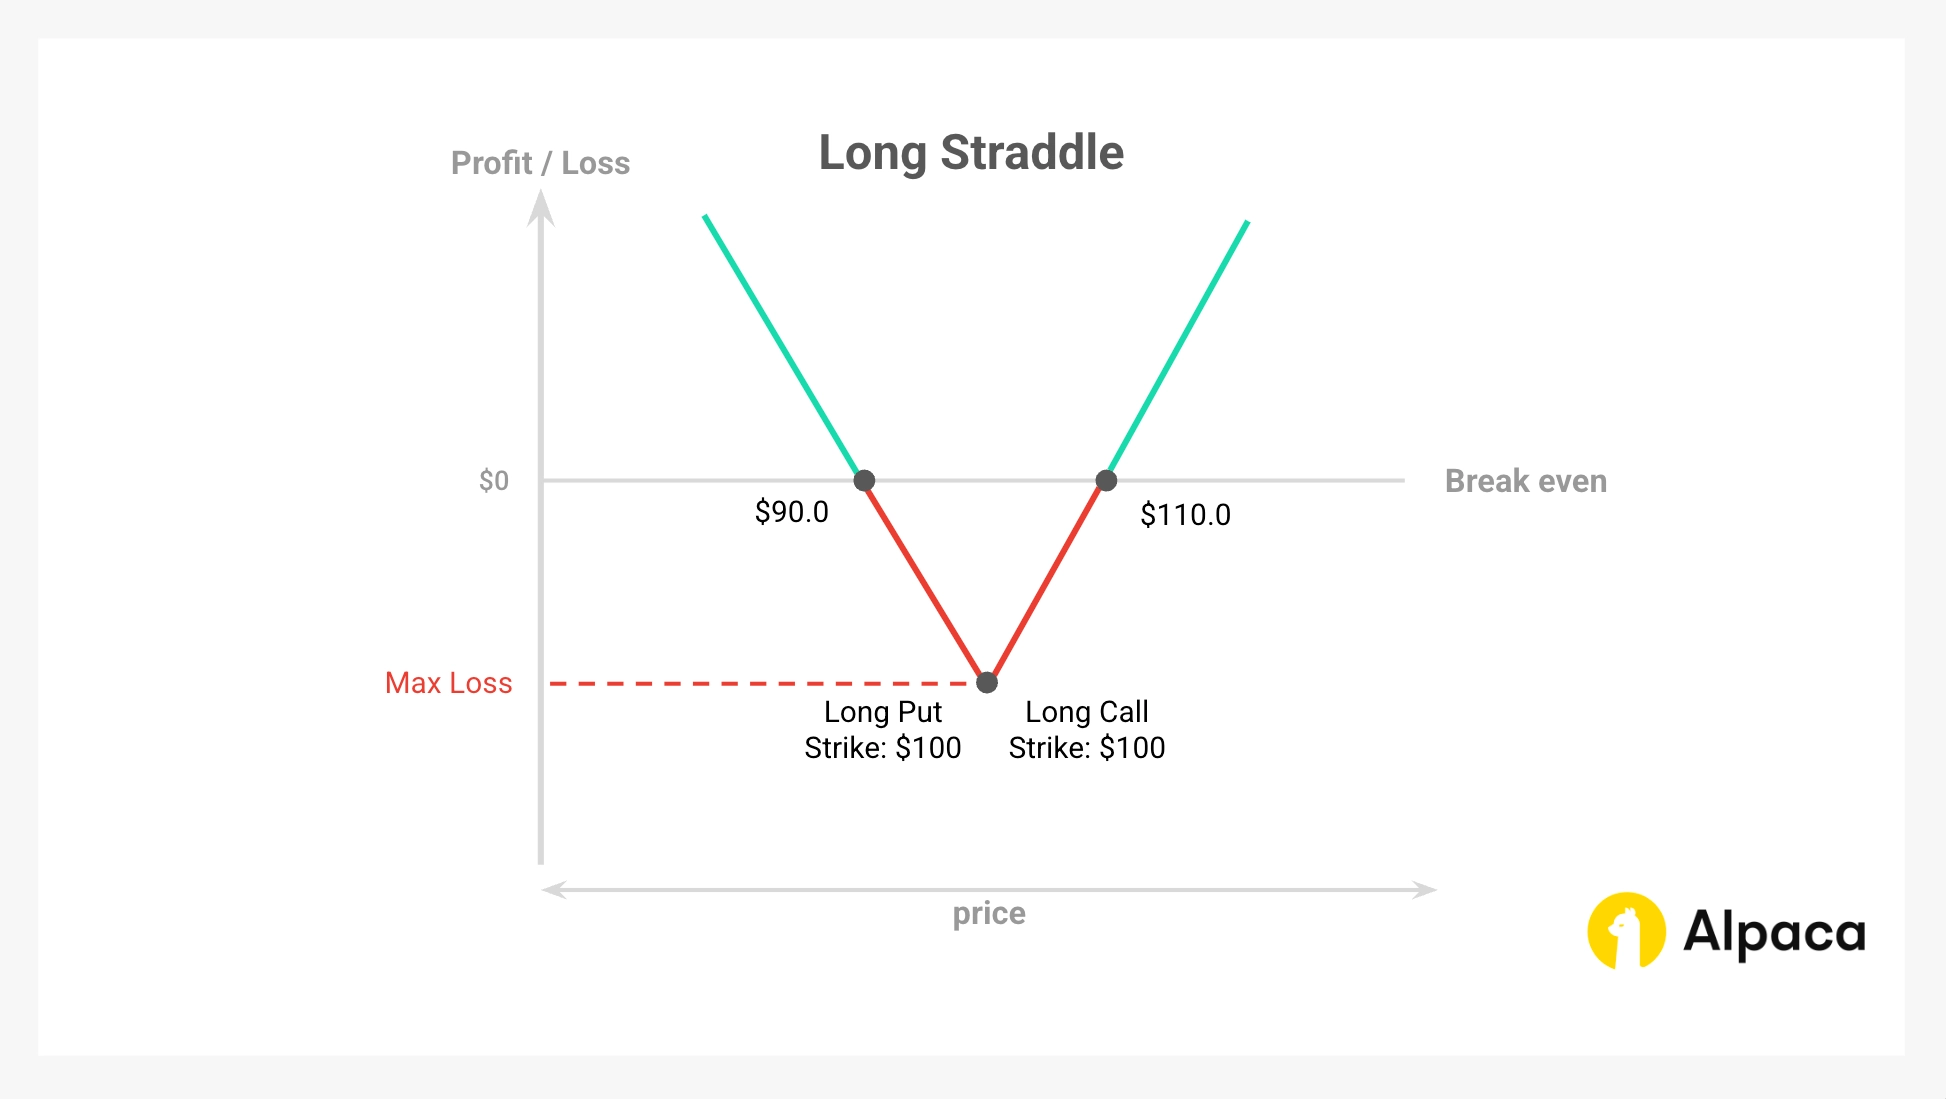

### ¿Cuándo usarlo?

El straddle es la apuesta más directa a **comprar volatilidad**. Es atractivo cuando:

- Crees que el mercado se va a mover mucho pero no sabes en qué dirección, antes de un dato de inflación, una decisión de la Fed, o resultados de earnings.
- Crees que la IV actual subestima el movimiento real que viene, el mercado está “dormido” pero tú ves una catálisis inminente.

Si compras un straddle y la IV sube aunque el precio no se mueva, la posición gana por vega. No necesitas esperar al vencimiento.

### Perfil de riesgo

La pérdida máxima es la suma de las dos primas pagadas, ocurre si SPY termina exactamente en K. La ganancia es ilimitada en ambas direcciones. Los break-evens son $K \pm (C + P)$.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    # Línea de precio actual
    if S0 is not None:
        plt.axvline(S0, color='blue', linestyle='--', linewidth=1, label=f'S0={S0}')

    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Costo total        : $27.87
Break-even sup.    : $707.87
Break-even inf.    : $652.13
Pérdida máxima     : $-27.87  (si ST =680)


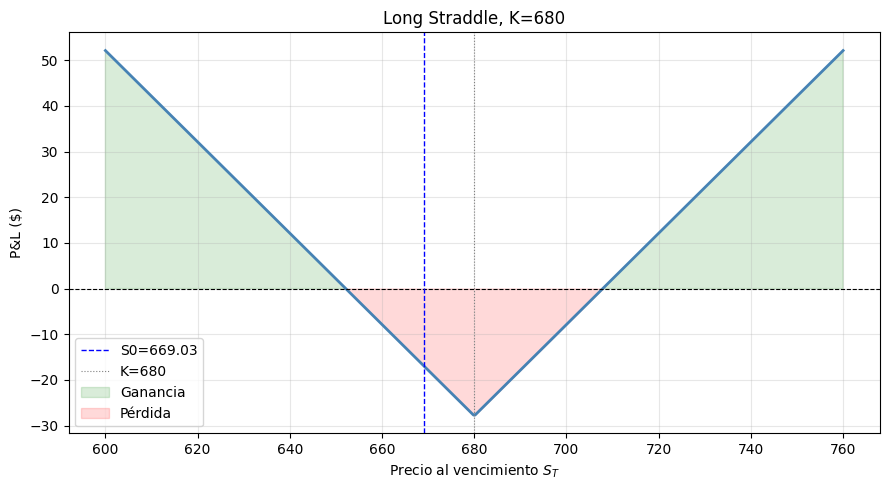

In [9]:
S_range = np.linspace(600, 760, 500)
K, C, P, S0 = 680, 9.37, 18.50, 669.03

legs_straddle = [
    {'tipo': 'call', 'K': K, 'prima': C, 'posicion': +1},
    {'tipo': 'put',  'K': K, 'prima': P, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_straddle)

print(f"Costo total        : ${C+P:.2f}")
print(f"Break-even sup.    : ${K+C+P:.2f}")
print(f"Break-even inf.    : ${K-C-P:.2f}")
print(f"Pérdida máxima     : ${-(C+P):.2f}  (si ST ={K})")

graficar_estrategia(S_range, pnl, f'Long Straddle, K={K}', S0=S0, K_lines=[(K, f'K={K}')])

## 3. Long Strangle

### ¿Qué es?

Similar al straddle, pero compras el call y el put con **strikes distintos**, el call OTM y el put OTM. Es más barato porque ambas opciones están fuera del dinero, pero requiere un movimiento mayor para ser rentable.

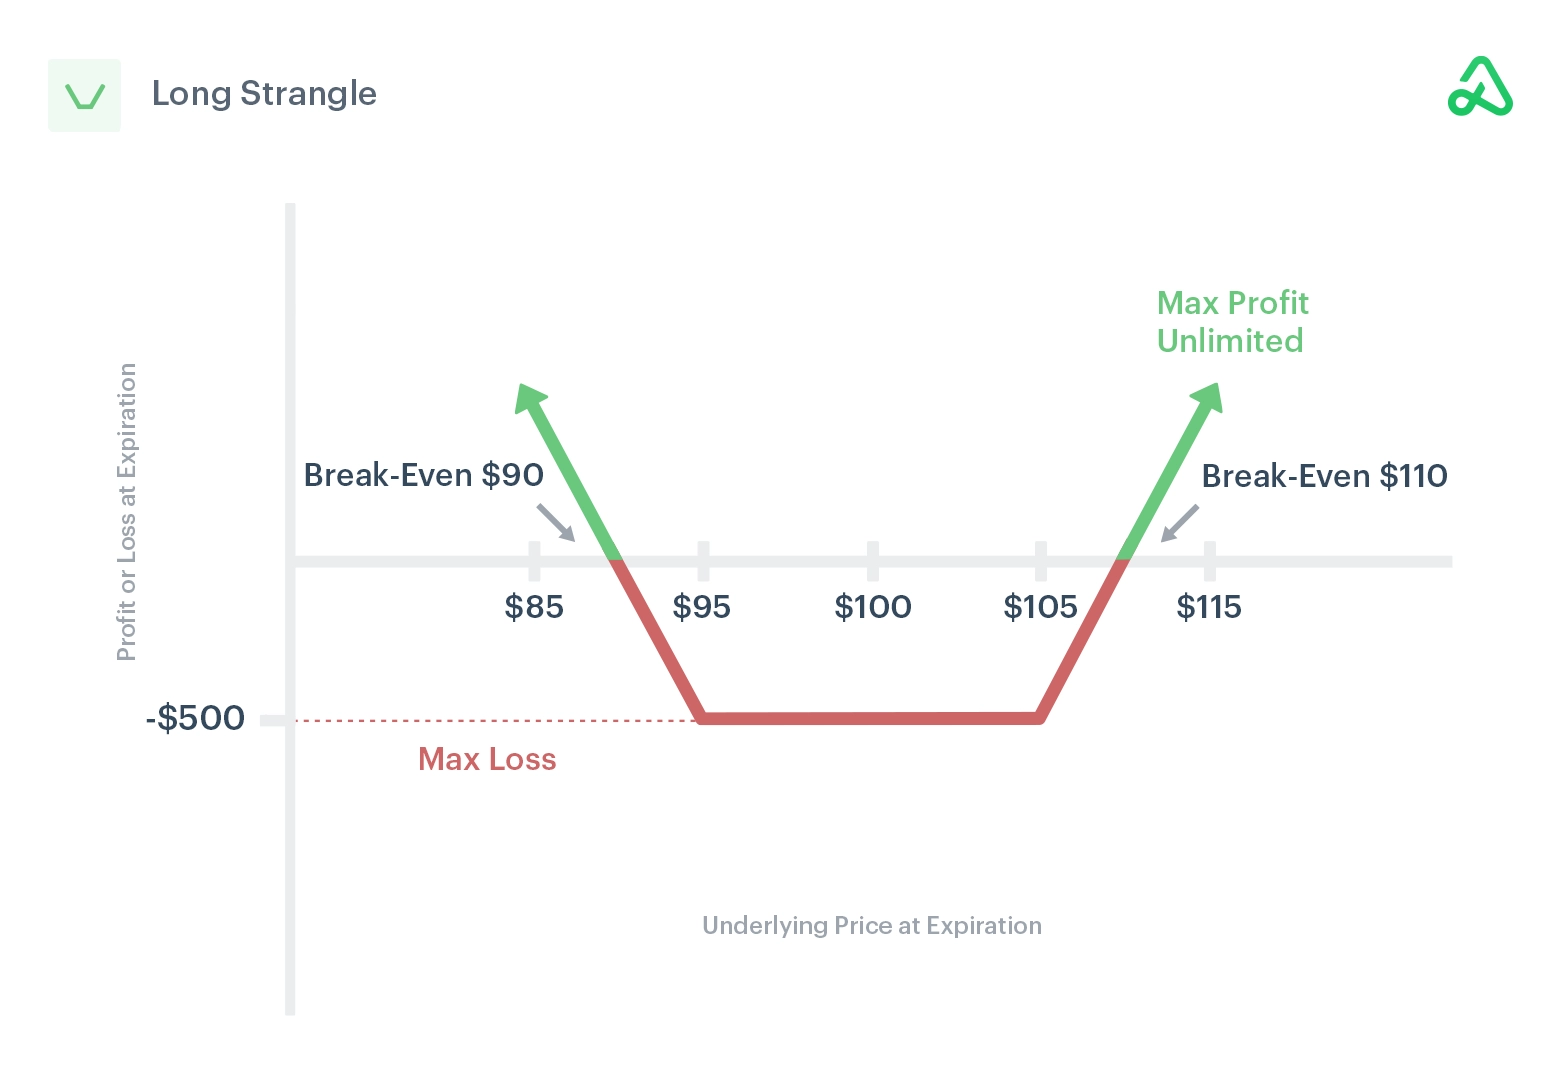

### ¿Cuándo preferirlo sobre el straddle?

El strangle es la versión más barata de comprar volatilidad. Tiene sentido cuando:

- Crees que el movimiento vendrá pero tendrás que esperar, el tiempo te daña menos porque pagaste menos prima.
- Quieres reducir el costo de la posición aceptando que necesitas un movimiento más grande para ganar.

La zona de pérdida máxima del strangle es más ancha que la del straddle, hay un rango entre los dos strikes donde la posición pierde la prima total. Fuera de ese rango, ambas estrategias tienen ganancia ilimitada.

Costo total        : $16.00  (vs $27.87 del straddle)
Break-even sup.    : $716.00
Break-even inf.    : $644.00


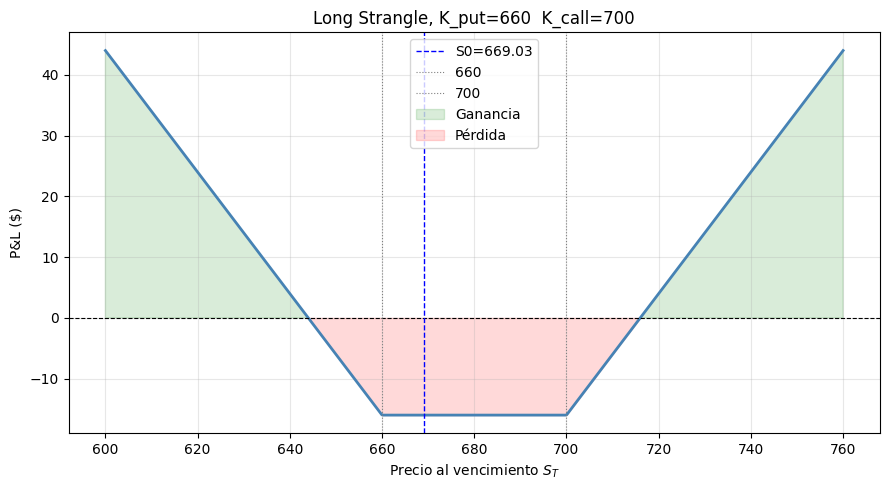

In [10]:
K_call, K_put = 700, 660
C_otm, P_otm  = 5.20, 10.80

legs_strangle = [
    {'tipo': 'call', 'K': K_call, 'prima': C_otm, 'posicion': +1},
    {'tipo': 'put',  'K': K_put,  'prima': P_otm,  'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_strangle)

print(f"Costo total        : ${C_otm+P_otm:.2f}  (vs ${C+P:.2f} del straddle)")
print(f"Break-even sup.    : ${K_call+C_otm+P_otm:.2f}")
print(f"Break-even inf.    : ${K_put-C_otm-P_otm:.2f}")

graficar_estrategia(S_range, pnl, f'Long Strangle, K_put={K_put}  K_call={K_call}',
                    S0=S0, K_lines=[(K_put, f'{K_put}'), (K_call, f'{K_call}')])

## 4. Bull Call Spread

### ¿Qué es?

Compra un call con strike bajo K1 y vende un call con strike alto K2. El call vendido financia parcialmente el comprado, reduces el costo a cambio de limitar la ganancia máxima al rango entre los dos strikes. A veces también son llamados long call spreads.

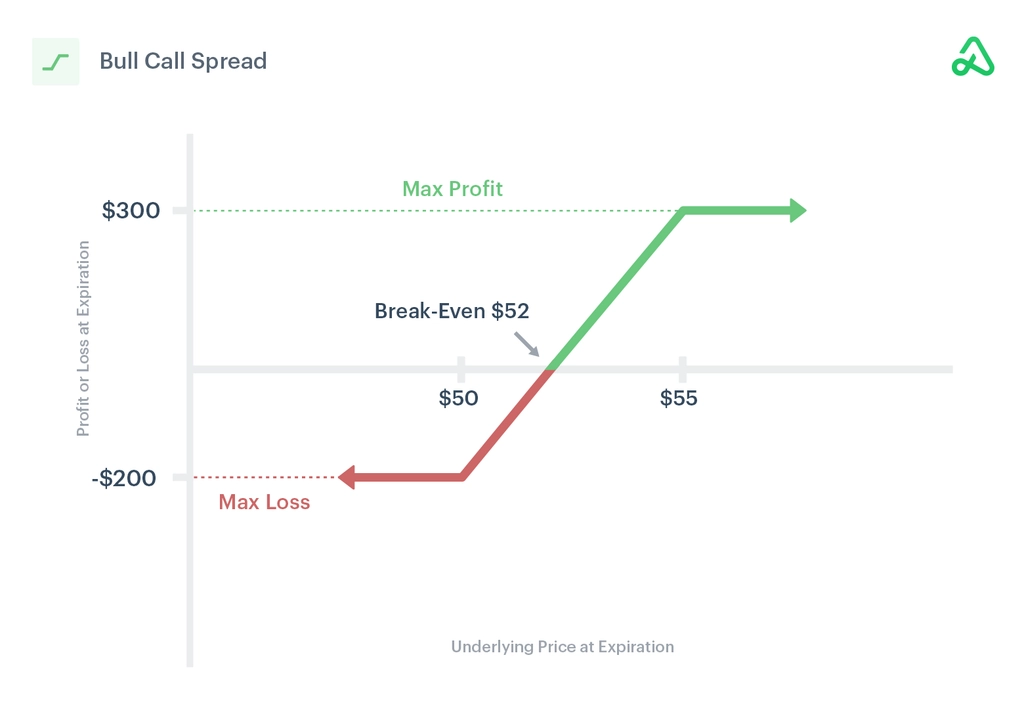

Ejemplo con un $5 wide bull call spread que costó $2.00 netos (Prima pagada - Prima recibida). Compras un call con strike de $50 (long call) Vendes un call con strike de $55 (short call).

### ¿Cuándo usarlo?

El bull spread es la herramienta cuando tienes una visión **alcista moderada**: crees que el precio subirá, pero no indefinidamente. Tiene sentido cuando:

- Esperas una subida hasta un nivel específico pero no más, por ejemplo, SPY de 669 a 700, pero no mucho más allá.
- Quieres exposición alcista a menor costo que un call simple.
- La IV está alta y no quieres pagar tanto por el call, el spread reduce el costo neto.

La ganancia máxima es $K_2 - K_1 - \text{prima neta}$. La pérdida máxima es la prima neta pagada.

Prima neta pagada  : $9.30
Ganancia máxima    : $20.70  (si ST ≥700)
Pérdida máxima     : $-9.30  (si ST ≤670)
Break-even         : $679.30


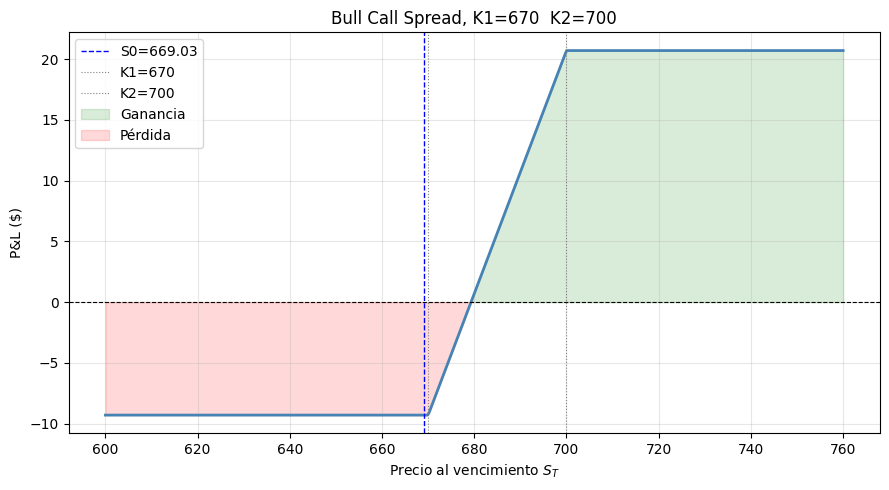

In [11]:
K1, K2 = 670, 700
C1, C2 = 14.50, 5.20

legs_bull = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -1},
]
pnl = payoff_estrategia(S_range, legs_bull)
prima_neta = C1 - C2

print(f"Prima neta pagada  : ${prima_neta:.2f}")
print(f"Ganancia máxima    : ${(K2-K1)-prima_neta:.2f}  (si ST ≥{K2})")
print(f"Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≤{K1})")
print(f"Break-even         : ${K1+prima_neta:.2f}")

graficar_estrategia(S_range, pnl, f'Bull Call Spread, K1={K1}  K2={K2}',
                    S0=S0, K_lines=[(K1, f'K1={K1}'), (K2, f'K2={K2}')])

## 5. Bear Put Spread

### ¿Qué es?

Compra un put con strike alto K1 y vende un put con strike bajo K2. Es la imagen especular del bull spread, apuesta a una caída moderada, con ganancia limitada y costo reducido.

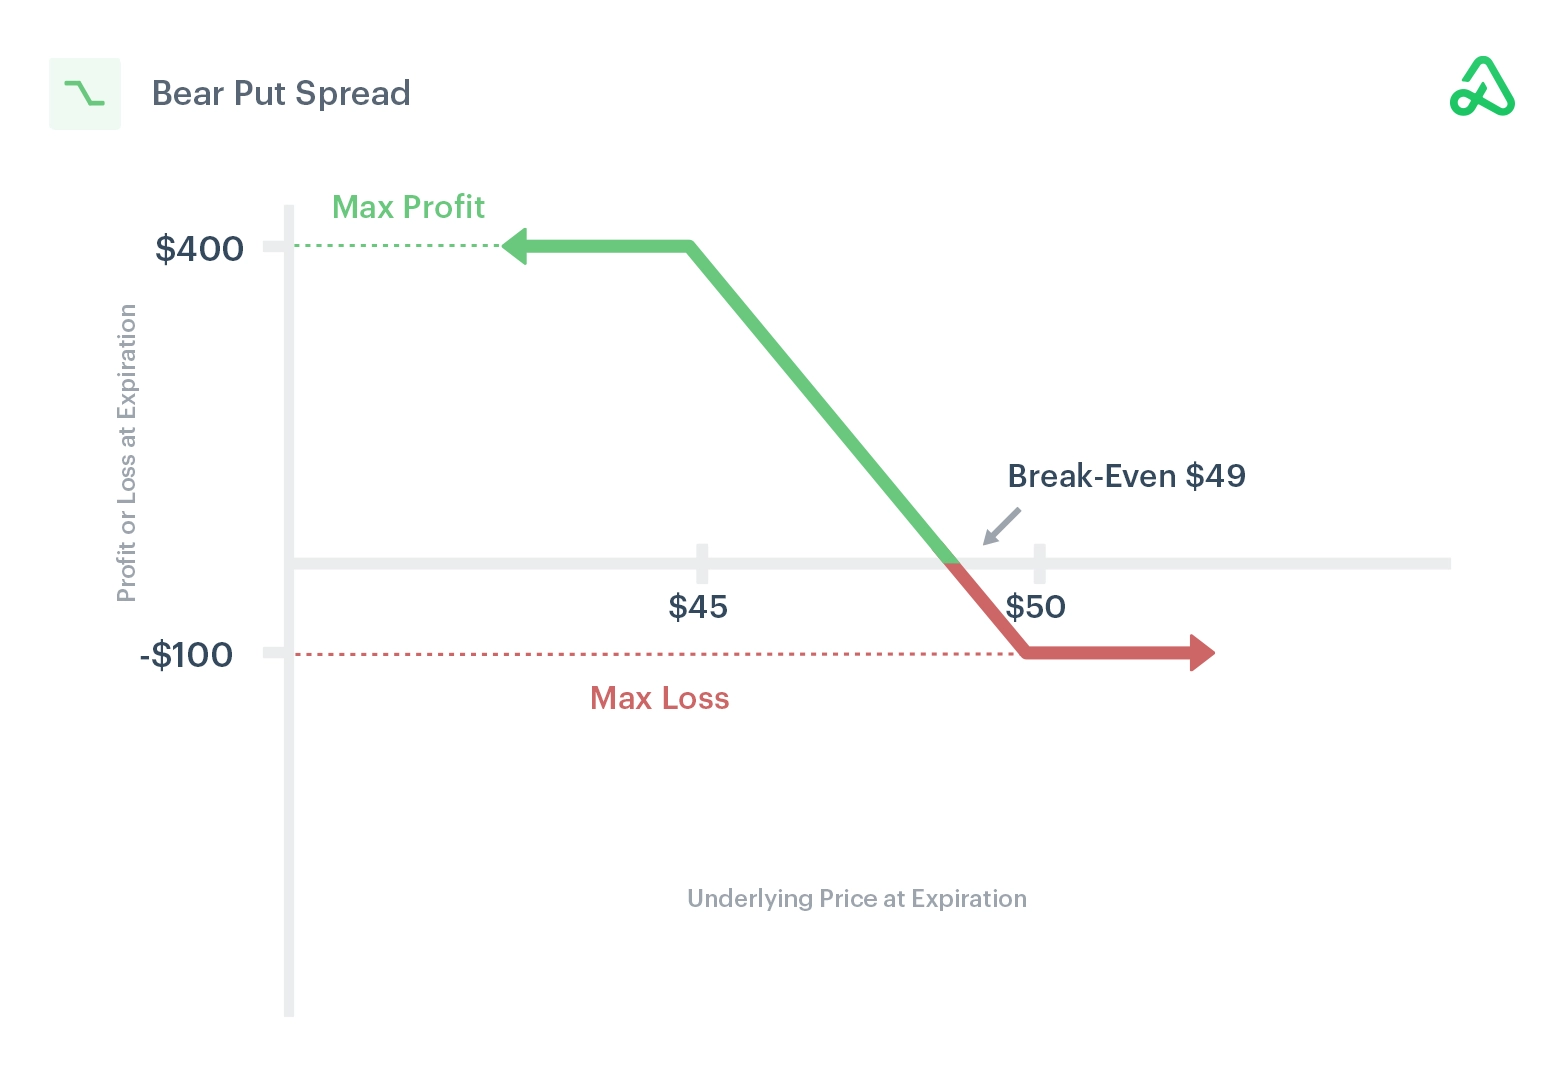

Spread de $5 de ancho que cuesta $1.00 de prima neta. Compras un put con strike de $50 (long put): el strike más alto. Vendes un put con strike de $45 (short put): el strike más bajo.

### ¿Cuándo usarlo?

El bear spread es la versión de bajo costo de la visión bajista. Tiene sentido cuando:

- Esperas una corrección hasta un nivel específico, por ejemplo, SPY de 669 a 640, pero no una caída catastrófica.
- Quieres protección downside más barata que un put simple

Prima neta pagada  : $10.30
Ganancia máxima    : $19.70  (si ST ≤650)
Pérdida máxima     : $-10.30  (si ST ≥680)
Break-even         : $669.70


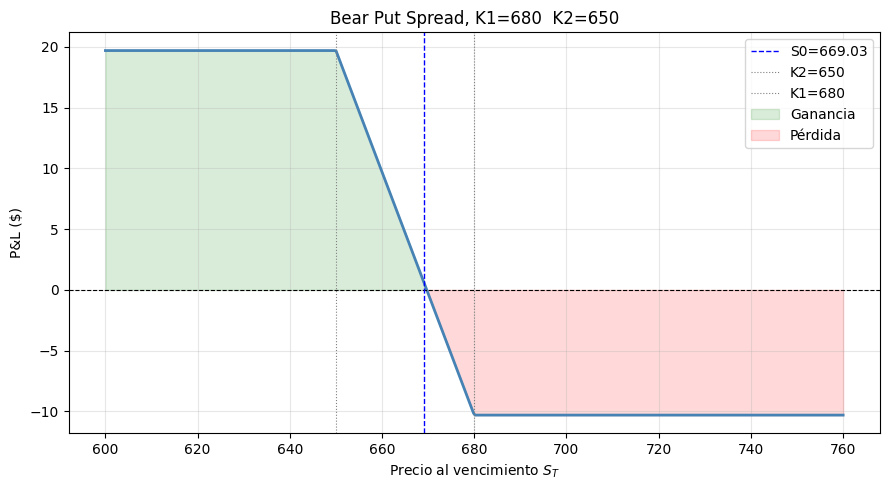

In [12]:
K1, K2 = 680, 650
P1, P2 = 18.50, 8.20

legs_bear = [
    {'tipo': 'put', 'K': K1, 'prima': P1, 'posicion': +1},
    {'tipo': 'put', 'K': K2, 'prima': P2, 'posicion': -1},
]
pnl = payoff_estrategia(S_range, legs_bear)
prima_neta = P1 - P2

print(f"Prima neta pagada  : ${prima_neta:.2f}")
print(f"Ganancia máxima    : ${(K1-K2)-prima_neta:.2f}  (si ST ≤{K2})")
print(f"Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≥{K1})")
print(f"Break-even         : ${K1-prima_neta:.2f}")

graficar_estrategia(S_range, pnl, f'Bear Put Spread, K1={K1}  K2={K2}',
                    S0=S0, K_lines=[(K2, f'K2={K2}'), (K1, f'K1={K1}')])

## 6. Tabla resumen

| Estrategia | Vista del mercado | Ganancia máx. | Pérdida máx. | Vega |
| --- | --- | --- | --- | --- |
| Long Straddle | Se mueve mucho (cualquier dir.) | Ilimitada | C + P | Positiva |
| Long Strangle | Se mueve mucho (cualquier dir.) | Ilimitada | C + P (menor) | Positiva |
| Bull Call Spread | Sube moderadamente | K2 - K1 - prima | Prima neta | Casi neutral |
| Bear Put Spread | Baja moderadamente | K1 - K2 - prima | Prima neta | Casi neutral |

La columna de vega comunica algo importante: straddle y strangle son explícitamente apuestas a volatilidad, si IV sube, ganan aunque el precio no se mueva. Los spreads son más neutrales a IV porque el call o put vendido compensa parcialmente la vega del comprado.

---

Referencias:

https://alpaca.markets/learn/long-straddle

https://optionalpha.com/strategies/long-strangle

## Rep. 4. Checkpoint 2. Estrategias 1

Usando el código visto en clase y datos reales de SPY con vencimiento al 17 de abril de 2026, replicarás los payoff diagrams de las cuatro estrategias direccionales (long straddle, long strangle, bull call spread y bear put spread) y analizarás qué visión de mercado expresa cada una.

### Contexto

Una estrategia direccional no es solo una combinación de opciones: es la traducción de una tesis de mercado a una estructura de pagos concreta. Antes de entrar a una posición multi-pierna, un trader construye el payoff diagram para entender exactamente bajo qué condiciones gana, cuánto puede perder, y qué tan sensible es a cambios en volatilidad implícita. La misma visión bajista puede expresarse con un put simple, un bear spread o un short call, y cada estructura tiene un perfil distinto de riesgo, costo y exposición a las griegas.

### Instrucciones

Toma el código desarrollado en clase para las cuatro estrategias direccionales (long straddle, long strangle, bull call spread y bear put spread) y ejecútalo en tu notebook usando los precios mid reales de SPY con vencimiento 2026-04-17, obtenidos dinámicamente con yfinance (siguiendo el mismo patrón visto en clase). No necesitas escribir código nuevo: la actividad consiste en correr el código de clase con datos actualizados y presentar:

- El payoff diagram del long straddle

- El payoff diagram del long strangle

- El payoff diagram del bull call spread

- El payoff diagram del bear put spread

Una tabla resumen con costo o prima neta, ganancia máxima, pérdida máxima y break-even(s) de cada estrategia (los valores ya se imprimen en el código de clase, basta con consolidarlos en una tabla)

In [14]:
import yfinance as yf
import pandas as pd

In [15]:
# Obtener datos actuales de SPY
spy = yf.Ticker("SPY")
spot_price = spy.history(period="1d")['Close'].iloc[-1]
print(f"Precio Spot actual de SPY: ${spot_price:.2f}")

Precio Spot actual de SPY: $674.78


In [17]:
# Obtener la cadena de opciones para el vencimiento especificado
expiration_date = '2026-04-17'
opts = spy.option_chain(expiration_date)
calls = opts.calls
puts = opts.puts

# Calcular precio mid: (Bid + Ask) / 2
calls['mid'] = (calls['bid'] + calls['ask']) / 2
puts['mid'] = (puts['bid'] + puts['ask']) / 2

In [18]:
# Definir los strikes (ATM y OTM) para construir las estrategias
atm_strike = round(spot_price)
otm_call_strike = atm_strike + 15  # Strike OTM superior (ajustable según preferencia)
otm_put_strike = atm_strike - 15   # Strike OTM inferior (ajustable)

print(f"Usando Strikes -> ATM: {atm_strike} | OTM Call: {otm_call_strike} | OTM Put: {otm_put_strike}\n")

Usando Strikes -> ATM: 675 | OTM Call: 690 | OTM Put: 660



In [19]:
# Función auxiliar para extraer la prima (precio mid) del strike más cercano disponible
def get_mid_price(df, strike_target):
    # Encuentra el strike listado más próximo al target por liquidez
    closest_strike = df.iloc[(df['strike'] - strike_target).abs().argsort()[:1]]['strike'].values[0]
    return df[df['strike'] == closest_strike]['mid'].values[0]

In [20]:
# Extraer las primas necesarias
c_atm = get_mid_price(calls, atm_strike)
p_atm = get_mid_price(puts, atm_strike)
c_otm = get_mid_price(calls, otm_call_strike)
p_otm = get_mid_price(puts, otm_put_strike)

In [21]:
# Crear funciones de payoff base y el rango del precio subyacente al vencimiento
S_T = np.linspace(atm_strike - 40, atm_strike + 40, 500)

def call_payoff(S_T, strike, premium):
    return np.maximum(S_T - strike, 0) - premium

def put_payoff(S_T, strike, premium):
    return np.maximum(strike - S_T, 0) - premium

In [22]:
# Construcción de Estrategias 
# A) Long Straddle (Compra Call ATM + Compra Put ATM)
payoff_straddle = call_payoff(S_T, atm_strike, c_atm) + put_payoff(S_T, atm_strike, p_atm)

# B) Long Strangle (Compra Call OTM + Compra Put OTM)
payoff_strangle = call_payoff(S_T, otm_call_strike, c_otm) + put_payoff(S_T, otm_put_strike, p_otm)

# C) Bull Call Spread (Compra Call ATM + Vende Call OTM)
payoff_bull_call = call_payoff(S_T, atm_strike, c_atm) - call_payoff(S_T, otm_call_strike, c_otm)

# D) Bear Put Spread (Compra Put ATM + Vende Put OTM)
payoff_bear_put = put_payoff(S_T, atm_strike, p_atm) - put_payoff(S_T, otm_put_strike, p_otm)

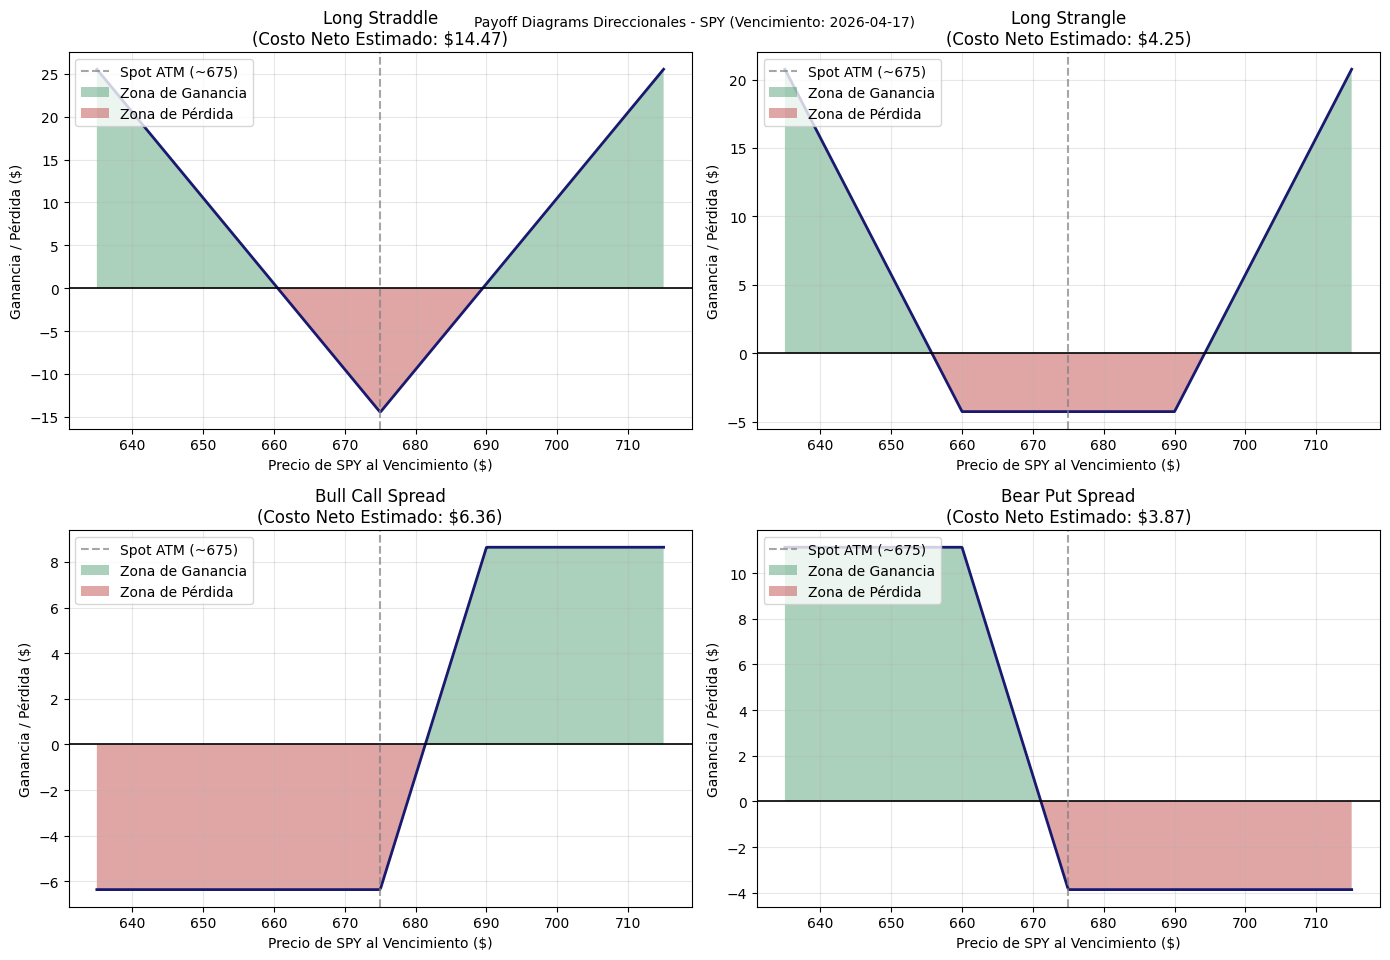

In [24]:
# Visualización: Graficar los Payoff Diagrams
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Payoff Diagrams Direccionales - SPY (Vencimiento: {expiration_date})', fontsize=10, y=0.95)

estrategias = [
    (axs[0, 0], payoff_straddle, 'Long Straddle', c_atm + p_atm),
    (axs[0, 1], payoff_strangle, 'Long Strangle', c_otm + p_otm),
    (axs[1, 0], payoff_bull_call, 'Bull Call Spread', c_atm - c_otm),
    (axs[1, 1], payoff_bear_put, 'Bear Put Spread', p_atm - p_otm)
]

for ax, payoff, title, cost in estrategias:
    ax.plot(S_T, payoff, color='midnightblue', lw=2)
    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(atm_strike, color='gray', linestyle='--', alpha=0.7, label=f'Spot ATM (~{atm_strike})')
    
    # Rellenar zonas de PnL
    ax.fill_between(S_T, payoff, 0, where=(payoff > 0), facecolor='seagreen', alpha=0.4, label='Zona de Ganancia')
    ax.fill_between(S_T, payoff, 0, where=(payoff < 0), facecolor='firebrick', alpha=0.4, label='Zona de Pérdida')
    
    ax.set_title(f'{title}\n(Costo Neto Estimado: ${cost:.2f})', fontsize=12)
    ax.set_xlabel('Precio de SPY al Vencimiento ($)', fontsize=10)
    ax.set_ylabel('Ganancia / Pérdida ($)', fontsize=10)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# 6. Tabla Resumen Consolidada
print("\n" + "="*80)
print(f"{'TABLA RESUMEN DE ESTRATEGIAS DIRECCIONALES SPY (Abril 2026)':^80}")
print("="*80)
print(f"{'Estrategia':<20} | {'Prima Neta ($)':<15} | {'Ganancia Máx ($)':<16} | {'Pérdida Máx ($)':<15}")
print("-" * 80)
print(f"{'Long Straddle':<20} | {c_atm + p_atm:<15.2f} | {'Ilimitada':<16} | {c_atm + p_atm:<15.2f}")
print(f"{'Long Strangle':<20} | {c_otm + p_otm:<15.2f} | {'Ilimitada':<16} | {c_otm + p_otm:<15.2f}")

# Para spreads, la ganancia máxima está topada por la diferencia de strikes menos la prima neta
max_profit_bull = (otm_call_strike - atm_strike) - (c_atm - c_otm)
max_profit_bear = (atm_strike - otm_put_strike) - (p_atm - p_otm)

print(f"{'Bull Call Spread':<20} | {c_atm - c_otm:<15.2f} | {max_profit_bull:<16.2f} | {c_atm - c_otm:<15.2f}")
print(f"{'Bear Put Spread':<20} | {p_atm - p_otm:<15.2f} | {max_profit_bear:<16.2f} | {p_atm - p_otm:<15.2f}")
print("="*80)


          TABLA RESUMEN DE ESTRATEGIAS DIRECCIONALES SPY (Abril 2026)           
Estrategia           | Prima Neta ($)  | Ganancia Máx ($) | Pérdida Máx ($)
--------------------------------------------------------------------------------
Long Straddle        | 14.47           | Ilimitada        | 14.47          
Long Strangle        | 4.25            | Ilimitada        | 4.25           
Bull Call Spread     | 6.36            | 8.64             | 6.36           
Bear Put Spread      | 3.87            | 11.13            | 3.87           



## Preguntas

Responde dentro del notebook como celdas de texto (Markdown). Las respuestas deben estar fundamentadas en tus propias gráficas con los datos reales del día que corras el código.

- **Con el S0 actual, ¿cuál de las cuatro estrategias está más cerca de su zona de máxima pérdida? ¿Qué te dice eso sobre la visión de mercado que expresa?** 

*Respuesta:* Con el S0 actual de 675, el Long Straddle se encuentra exactamente en su punto de máxima pérdida, formando el vértice inferior en tu gráfico. Basándonos en la Clase 21, esto nos dice que la estrategia expresa una visión de alta volatilidad pura / no direccional. Como la posición está estructurada con opciones compradas At-The-Money (ATM), asume que el precio actual no se mantendrá y que habrá un movimiento violento en cualquier dirección; si SPY se queda paralizado en 675, la posición pierde todo su valor.

- **Compara el costo total del long straddle vs. el long strangle que construiste. ¿Cuánto más barato es el strangle? ¿Cuánto más tiene que moverse SPY para que el strangle sea rentable comparado con el straddle?** 

*Respuesta:* El Long Strangle ($4.25) es $10.22 más barato que el Long Straddle ($14.47). Sin embargo, la Clase 21 explica que abaratar la entrada amplía la zona de pérdida.

Para el Straddle, SPY debe moverse $14.47 desde tu precio inicial para ser rentable (rebasar los 689.47 o caer de 660.53).

Para el Strangle, SPY tiene que alcanzar tus strikes OTM más la prima pagada. Necesita rebasar los 694.25 (690 + 4.25) o caer de 655.75 (660 - 4.25).
Esto significa que SPY debe moverse $19.25 desde el centro (675) en cualquier dirección. Para que el Strangle funcione, requieres que SPY se mueva $4.78 más de lo que exige el Straddle.

- **Un long straddle gana si el mercado se mueve mucho. ¿Qué pasa si compras el straddle justo después de que la IV ya subió por anticipación de un evento (por ejemplo, el día antes de earnings o de una decisión de la Fed)? ¿Sigue siendo una buena estrategia? Justifica.** 

*Respuesta:* No es una buena estrategia. La Clase 20 explica que "Vega es positiva para posiciones long". Dado que el Straddle consiste en dos opciones compradas, su Vega es altísima. Si compras cuando la Volatilidad Implícita (IV) ya subió, estás pagando un sobreprecio extremo (esos $14.47 podrían haber sido mucho menos en un entorno tranquilo). Pasado el evento, ocurre un "IV Crush" (la volatilidad colapsa) y, debido a nuestra Vega positiva, las opciones pierden valor extrínseco masivamente, generando pérdidas netas incluso si el precio S0 se mueve ligeramente.

- **El bull call spread limita la ganancia máxima comparado con un call simple. ¿Por qué alguien aceptaría ese límite voluntariamente? Da al menos dos razones.** 

*Respuesta:* Un trader acepta limitar su ganancia máxima (en tu caso a $8.64) principalmente por:

- **Reducción del costo y riesgo de capital:** Vender el Call OTM de 690 subsidia la compra del Call ATM de 675, bajando tu costo total a solo $6.36, lo cual también acerca tu punto de equilibrio (break-even).

- **Mitigación del decaimiento temporal (Theta):** La Clase 20 detalla que "quien compra opciones paga theta... quien las vende cobra theta". Al tener una pata corta (short) en el spread, la Theta positiva cobrada compensa la Theta negativa de la pata larga, frenando la pérdida de valor por el paso de los días.

- **Si tienes un bull spread abierto y SPY supera K2 antes del vencimiento, ¿tiene sentido cerrar la posición o esperar al vencimiento? ¿Qué factores considerarías para decidir?** 

*Respuesta:* Generalmente tiene sentido cerrar la posición. Si SPY supera tu K2 (690), ya has alcanzado tu ganancia máxima teórica ($8.64) en tu diagrama de pagos. La Clase 20 indica que "vender opciones implica tener gamma negativa". Al rebasar el strike vendido, tu delta se neutraliza y la gamma negativa frena cualquier beneficio adicional, pero mantienes el riesgo direccional de que SPY caiga por debajo de 690 antes del vencimiento y devuelva tus ganancias. Lo óptimo es asegurar la utilidad.

- **¿Cómo afecta un aumento de IV a un bull spread comparado con un long straddle? ¿Cuál de las dos posiciones es más sensible a cambios en volatilidad implícita y por qué?** 

*Respuesta:* El Long Straddle es muchísimo más sensible. Siguiendo la regla de la Clase 20 ("Vega es positiva para posiciones long y negativa para posiciones short"):

El Straddle suma dos opciones compradas (+Vega y +Vega), por lo que un aumento de IV dispara el valor de la posición a tu favor.

El Bull Spread mezcla una opción comprada (+Vega) y una vendida (-Vega). Ambas sensibilidades se contrarrestan, aislando a la estrategia de los cambios de volatilidad y haciéndola depender casi exclusivamente de la dirección del precio.

- **En términos de griegas (delta, gamma, vega, theta), ¿cuál es la diferencia principal entre comprar un call simple y comprar un bull call spread? ¿Qué griega cambia más drásticamente entre las dos estructuras?** 

*Respuesta:* Un Call simple es unidireccional en sus griegas (Delta positiva, Gamma positiva, Vega positiva, Theta negativa). Un Bull Call Spread estabiliza estas variables al introducir una pata corta que inyecta griegas de signo opuesto.
La griega que sufre el cambio estructural más drástico es la Gamma. Al comprar el call de 675 tienes Gamma positiva (tu delta acelera), pero al cruzar el strike de 690 que vendiste, la influencia de la pata corta predomina y tu Gamma neta se vuelve negativa (tu delta frena hasta volverse cero), lo cual es matemáticamente lo que genera la línea plana de ganancia máxima en tu gráfico superior derecho.